Numero di bande: 6
Risoluzione: 285x201
Valori della prima banda: [[506. 552. 552. ... 670. 866. 866.]
 [566. 544. 544. ... 718. 574. 574.]
 [564. 705. 705. ... 896. 715. 715.]
 ...
 [593. 683. 786. ... 588. 730. 667.]
 [472. 892. 672. ... 584. 698. 612.]
 [596. 698. 406. ... 590. 712. 803.]]


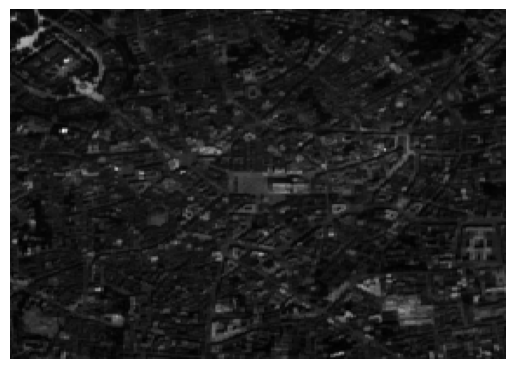

In [ ]:
import rasterio
import matplotlib.pyplot as plt


with rasterio.open('data/raw/S2_square_gee.tif') as src:
    print(f"Numero di bande: {src.count}")
    print(f"Risoluzione: {src.width}x{src.height}")
    
    
    band1 = src.read(1)

    print(f"Valori della prima banda: {band1}")
    
    
plt.imshow(band1, cmap='gray')
plt.axis('off')
plt.show()
    


File ID for 'S2_little_rock.tif': 1WUslLpe_O6RSf3zyXrE3S1wDmC5UqiPK
Numero di bande: 6
Risoluzione: 2423x2005
Valori della prima banda: [[ 886.  886. 1044. ...  366.  405.  250.]
 [ 706.  706.  886. ...  376.  422.  388.]
 [ 886.  886.  912. ...  390.  397.  428.]
 ...
 [ 308.  308.  175. ...  902.  902.  830.]
 [ 333.  333.  176. ...  738.  738.  697.]
 [  nan   nan   nan ...   nan   nan   nan]]
Valori della seconda banda: [[ 930.  930. 1044. ...  656.  608.  444.]
 [ 744.  744.  848. ...  662.  605.  539.]
 [ 812.  812.  872. ...  680.  618.  594.]
 ...
 [ 499.  499.  360. ...  900.  900.  850.]
 [ 461.  461.  307. ...  848.  848.  792.]
 [  nan   nan   nan ...   nan   nan   nan]]
Valori della terza banda: [[666. 666. 773. ... 328. 295. 225.]
 [532. 532. 650. ... 345. 346. 353.]
 [638. 638. 703. ... 324. 284. 318.]
 ...
 [302. 302. 192. ... 608. 608. 564.]
 [268. 268. 214. ... 504. 504. 476.]
 [ nan  nan  nan ...  nan  nan  nan]]


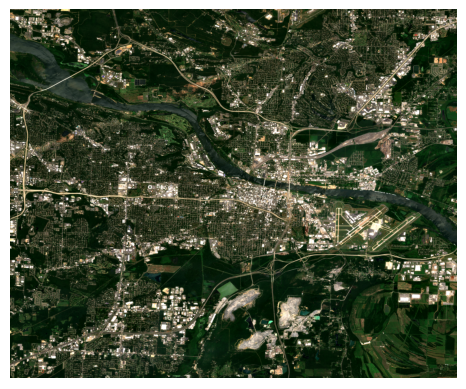

In [10]:
from Utils.Get_google_drive import get_tif_from_drive
from dotenv import load_dotenv
import io
import os
import rasterio
import matplotlib.pyplot as plt
import numpy as np

load_dotenv()

raw_data = get_tif_from_drive("S2_little_rock.tif", os.getenv("GOOGLE_CLOUD_CREDENTIALS"))
file_tif = io.BytesIO(raw_data)

with rasterio.open(file_tif) as src:
    print(f"Numero di bande: {src.count}")
    print(f"Risoluzione: {src.width}x{src.height}")
    
   
    band1 = src.read(3)
    band2 = src.read(2)
    band3 = src.read(1)

    rgb_image = np.dstack([band1, band2, band3])
    print(f"Valori della prima banda: {band1}")
    print(f"Valori della seconda banda: {band2}")
    print(f"Valori della terza banda: {band3}")
    
p_min, p_max = np.nanpercentile(rgb_image, (2, 98))
rgb_normalizzata = np.clip((rgb_image - p_min) / (p_max - p_min), 0, 1)
plt.imshow(rgb_normalizzata)
plt.axis('off')
plt.show()
